Согласно варианту, сигнал задаётся формулой:

$$x_2(t)=\frac{a_2}{b_2+|t-t_2|}e^{-c_2|t-t_3|}\,\mathrm{sinc}(d_2t)$$

Параметры сигнала:  $a_2=-2,\quad b_2=5,\quad t_2=2,\quad c_2=0.2,\quad t_3=-3,\quad d_2=5$

Для численного анализа сигнал аппроксимируется на конечном интервале времени:  
$$t_{\min}=-10,\quad t_{\max}=10$$

Выбрано число точек дискретизации $N=1000$.  
Шаг дискретизации:  
$$a=\frac{t_{\max}-t_{\min}}{N}=\frac{10-(-10)}{1000}=0.02$$

Интервал частот выбран симметричным: $\lambda_{\min}=-20,\;\lambda_{\max}=20$, число точек по частоте $M=2000$.

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import time

In [11]:
def signal_func(t):
    a2 = -2.0
    b2 = 5.0
    t2 = 2.0
    c2 = 0.2
    t3 = -3.0
    d2 = 5.0
    return (a2 / (b2 + np.abs(t - t2))) * np.exp(-c2 * np.abs(t - t3)) * np.sinc(d2 * t)

t_min = -10.0
t_max = 10.0
N = 1000
a = (t_max - t_min) / N

lam_min = -20.0
lam_max = 20.0
M = 2000
s = (lam_max - lam_min) / M

t = np.linspace(t_min, t_max, N)
lam = np.linspace(lam_min, lam_max, M)
x = signal_func(t)

Для вычисления преобразования Фурье используется метод прямоугольников (матричное умножение).  
Прямое преобразование:  
$$\hat{x}(\lambda) \approx a \sum_{n=0}^{N-1} x(t_{\min}+an)\, e^{-2\pi i (t_{\min}+an)\lambda}$$

Обратное преобразование:  
$$x(t) \approx s \sum_{k=0}^{M-1} \hat{x}(\lambda_{\min}+sk)\, e^{2\pi i (\lambda_{\min}+sk)t}$$

In [12]:
def dft(x, t, lam):
    dt = t[1] - t[0]
    X = np.zeros(len(lam), dtype=complex)
    for i, l in enumerate(lam):
        X[i] = dt * np.sum(x * np.exp(-2j * np.pi * l * t))
    return X

def idft(X, lam, t):
    dlam = lam[1] - lam[0]
    x_rec = np.zeros(len(t), dtype=complex)
    for i, ti in enumerate(t):
        x_rec[i] = dlam * np.sum(X * np.exp(2j * np.pi * lam * ti))
    return x_rec

Вычисляем спектр исходного сигнала и строим его амплитудно-частотную характеристику (АЧХ).

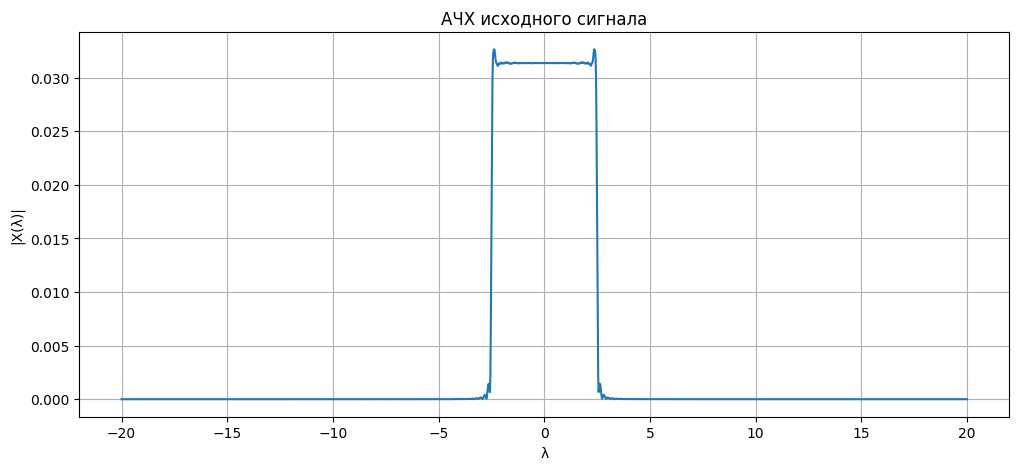

In [13]:
X_original = dft(x, t, lam)

plt.figure(figsize=(12,5))
plt.plot(lam, np.abs(X_original))
plt.title('АЧХ исходного сигнала')
plt.xlabel('λ')
plt.ylabel('|X(λ)|')
plt.grid(True)
plt.show()

Спектр непрерывный, симметричен относительно нулевой частоты, основная энергия сосредоточена в области низких частот ($|\lambda|<2$). Это согласуется с ожидаемым поведением сигнала, содержащего быстроосциллирующую функцию $\mathrm{sinc}(5t)$.

Цель фильтрации – подавление высокочастотных составляющих. По АЧХ видно, что значимые частоты лежат в пределах $|\lambda| < 2$. Поэтому выбираем полосу пропускания $[-\lambda_F,\lambda_F]$ с $\lambda_F = 2$.  
Пропускание сигнала через идеальный фильтр выполняется двумя способами:  
1. **Частотный метод** – умножение спектра на передаточную функцию фильтра $H(\lambda)=1$ для $|\lambda|\le \lambda_F$ и $0$ иначе, затем обратное ПФ.  
2. **Метод свёртки** – свёртка сигнала с импульсной характеристикой фильтра $h(t)=2\lambda_F\,\mathrm{sinc}(2\lambda_F t)$.

In [14]:
lambda_F = 2.0
print(f'Граничная частота фильтра: λF = {lambda_F}')

H_ideal = np.where(np.abs(lam) <= lambda_F, 1.0, 0.0)
Y_ideal_freq = X_original * H_ideal
y_ideal_freq = idft(Y_ideal_freq, lam, t).real

Граничная частота фильтра: λF = 2.0


In [15]:
def h_ideal(t):
    return 2 * lambda_F * np.sinc(2 * lambda_F * t)

# Выбор интервала для импульсной характеристики (h(t) затухает как 1/t)
t_h_min = -10.0
t_h_max = 10.0
K = int((t_h_max - t_h_min) / a) + 1
t_h = np.linspace(t_h_min, t_h_max, K)
h = h_ideal(t_h)

y_ideal_conv = a * np.convolve(x, h, mode='full')
t_conv_ideal = np.linspace(t_min + t_h_min, t_max + t_h_max, len(y_ideal_conv))

На графике показаны исходный сигнал и результаты фильтрации двумя методами.

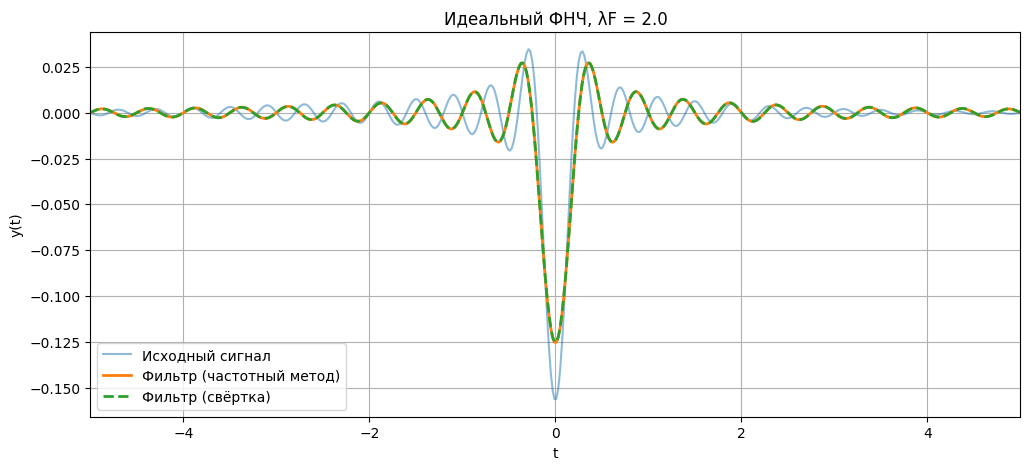

In [16]:
plt.figure(figsize=(12,5))
plt.plot(t, x, label='Исходный сигнал', alpha=0.5)
plt.plot(t, y_ideal_freq, label='Фильтр (частотный метод)', linewidth=2)
plt.plot(t_conv_ideal, y_ideal_conv, '--', label='Фильтр (свёртка)', linewidth=2)
plt.title('Идеальный ФНЧ, λF = {:.1f}'.format(lambda_F))
plt.xlabel('t')
plt.ylabel('y(t)')
plt.legend()
plt.grid(True)
plt.xlim(-5, 5)
plt.show()

Оба метода дают практически одинаковый результат, что подтверждает эквивалентность фильтрации в частотной и временной областях. Фильтр эффективно подавляет высокочастотные колебания, оставляя низкочастотную составляющую сигнала. Небольшие расхождения на краях графика связаны с граничными эффектами при свёртке (выбор конечного интервала импульсной характеристики).

В качестве аппроксимации идеального фильтра используется RC-цепочка (фильтр нижних частот первого порядка).  
Параметр RC подбирается так, чтобы частота среза совпадала с $\lambda_F$:  
$$RC = \frac{1}{2\pi \lambda_F}$$

Передаточная функция: $H(\lambda) = \frac{1}{1 + j 2\pi \lambda RC}$  
Импульсная характеристика: $h(t) = \frac{1}{RC} e^{-t/RC} u(t)$

Фильтрация выполняется аналогично идеальному фильтру.

In [17]:
RC = 1.0 / (2 * np.pi * lambda_F)
print(f'Параметр RC = {RC:.4f}')

H_rc = 1.0 / (1 + 1j * 2 * np.pi * lam * RC)
Y_rc_freq = X_original * H_rc
y_rc_freq = idft(Y_rc_freq, lam, t).real

Параметр RC = 0.0796


In [18]:
def h_rc(t):
    return (1.0/RC) * np.exp(-t/RC) * (t >= 0)

t_h_max_rc = 5 * RC   # h(t_h_max_rc) = e^{-5} ≈ 0.0067
t_h_min_rc = 0.0
K_rc = int((t_h_max_rc - t_h_min_rc) / a) + 1
t_h_rc = np.linspace(t_h_min_rc, t_h_max_rc, K_rc)
h_rc_sampled = h_rc(t_h_rc)

y_rc_conv = a * np.convolve(x, h_rc_sampled, mode='full')
t_conv_rc = np.linspace(t_min + t_h_min_rc, t_max + t_h_max_rc, len(y_rc_conv))

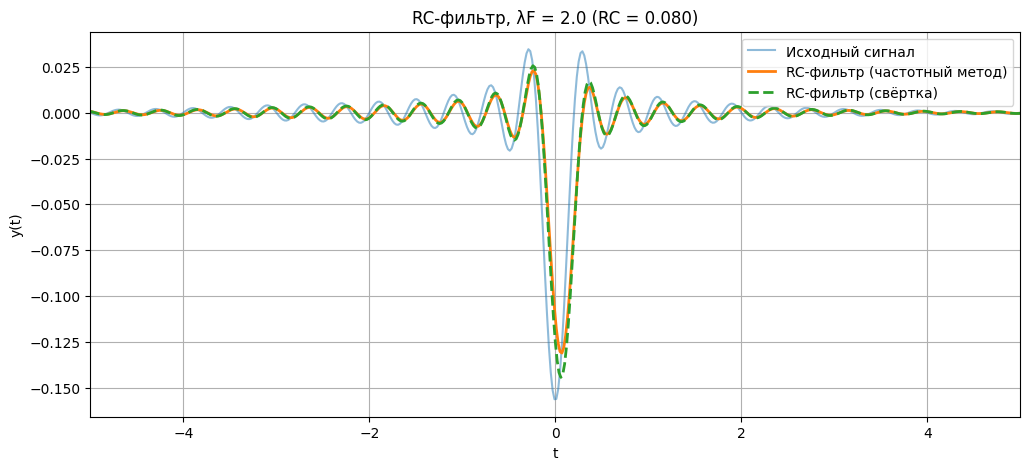

In [19]:
plt.figure(figsize=(12,5))
plt.plot(t, x, label='Исходный сигнал', alpha=0.5)
plt.plot(t, y_rc_freq, label='RC-фильтр (частотный метод)', linewidth=2)
plt.plot(t_conv_rc, y_rc_conv, '--', label='RC-фильтр (свёртка)', linewidth=2)
plt.title('RC-фильтр, λF = {:.1f} (RC = {:.3f})'.format(lambda_F, RC))
plt.xlabel('t')
plt.ylabel('y(t)')
plt.legend()
plt.grid(True)
plt.xlim(-5, 5)
plt.show()

Результаты, полученные частотным методом и свёрткой, совпадают. RC-фильтр сглаживает сигнал, но в отличие от идеального фильтра не обрезает частоты резко, а подавляет их плавно. Это видно по более медленному переходу выходного сигнала и меньшей степени подавления высокочастотных осцилляций.

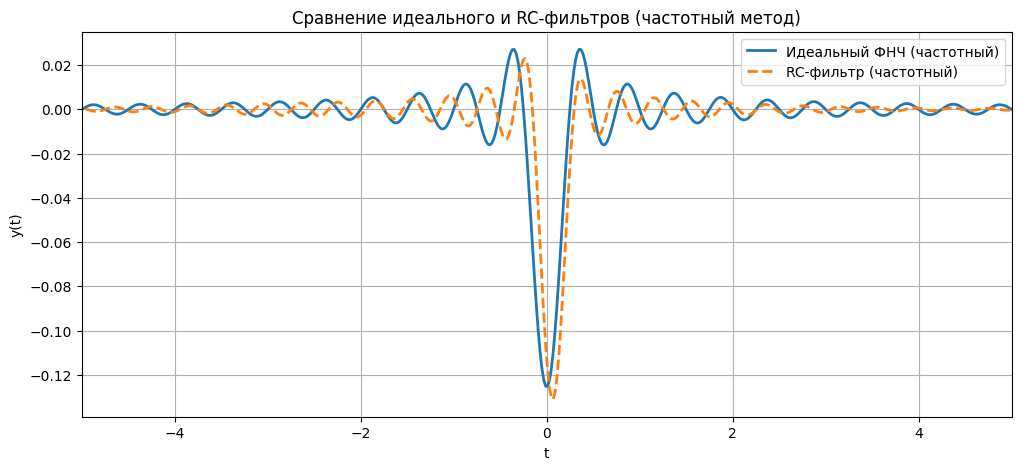

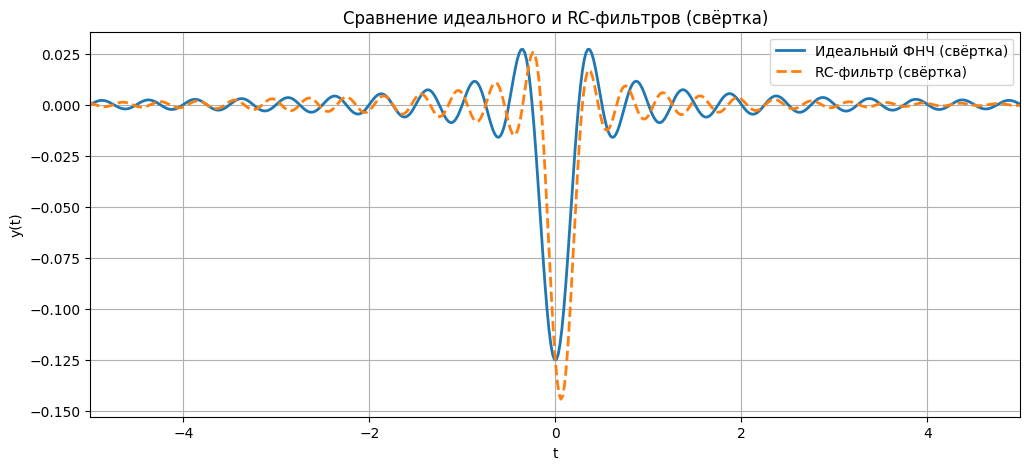

In [20]:
# Сравнение фильтров
plt.figure(figsize=(12,5))
plt.plot(t, y_ideal_freq, label='Идеальный ФНЧ (частотный)', linewidth=2)
plt.plot(t, y_rc_freq, '--', label='RC-фильтр (частотный)', linewidth=2)
plt.title('Сравнение идеального и RC-фильтров (частотный метод)')
plt.xlabel('t')
plt.ylabel('y(t)')
plt.legend()
plt.grid(True)
plt.xlim(-5, 5)
plt.show()

plt.figure(figsize=(12,5))
plt.plot(t_conv_ideal, y_ideal_conv, label='Идеальный ФНЧ (свёртка)', linewidth=2)
plt.plot(t_conv_rc, y_rc_conv, '--', label='RC-фильтр (свёртка)', linewidth=2)
plt.title('Сравнение идеального и RC-фильтров (свёртка)')
plt.xlabel('t')
plt.ylabel('y(t)')
plt.legend()
plt.grid(True)
plt.xlim(-5, 5)
plt.show()

- Идеальный фильтр обеспечивает резкое подавление частот выше $\lambda_F$, что приводит к более чистой низкочастотной составляющей.  
- RC-фильтр является физически реализуемым и имеет плавную характеристику, поэтому его выходной сигнал содержит остаточные высокочастотные компоненты.  
- Оба фильтра демонстрируют согласованность результатов при использовании частотного подхода и свёртки, что подтверждает корректность вычислений.

Таким образом, RC-цепочка может служить простой аппроксимацией идеального фильтра, однако для более точного подавления высоких частот требуется фильтр более высокого порядка.